Создаю GIF... Это может занять несколько секунд.
Готово! Файл 'convolution.gif' сохранен в текущей папке.


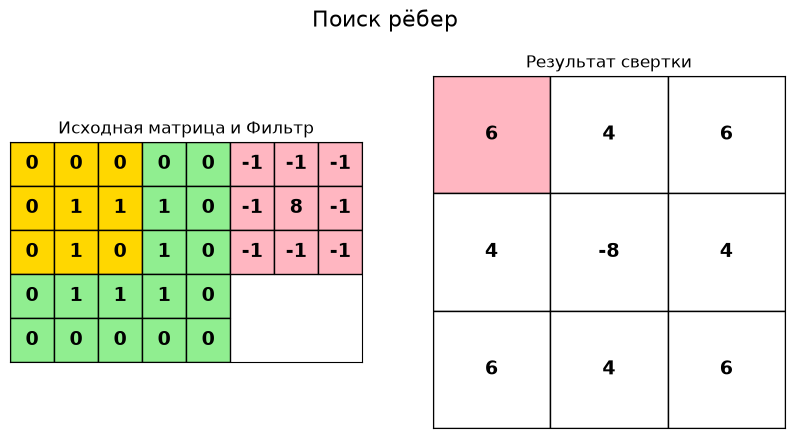

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Твои исходные данные
img = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,1,0,1,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
])

filt = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Размеры
img_h, img_w = img.shape
filt_h, filt_w = filt.shape
out_h, out_w = img_h - filt_h + 1, img_w - filt_w + 1

# Матрица результатов
out = np.zeros((out_h, out_w))

# 2. Настройка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Поиск рёбер', fontsize=16)

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Текущая позиция фильтра
    i = frame // out_w
    j = frame % out_w
    
    # --- ЛЕВАЯ ЧАСТЬ: Исходная матрица и фильтр ---
    ax1.set_title("Исходная матрица и Фильтр", fontsize=12)
    ax1.set_xlim(-0.5, img_w + filt_w - 0.5)
    ax1.set_ylim(img_h - 0.5, -0.5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_aspect('equal')
    
    # Рисуем исходную матрицу
    for r in range(img_h):
        for c in range(img_w):
            # Подсветка текущего окна
            if i <= r < i + filt_h and j <= c < j + filt_w:
                color = '#FFD700' # Золотой
            else:
                color = '#90EE90' # Салатовый
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(c, r, str(img[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Рисуем фильтр рядом (сдвигаем вправо)
    for r in range(filt_h):
        for c in range(filt_w):
            rect = plt.Rectangle((img_w + c - 0.5, r - 0.5), 1, 1, facecolor='#FFB6C1', edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(img_w + c, r, str(filt[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Текст с расчетом
    window = img[i:i+filt_h, j:j+filt_w]
    calc_sum = np.sum(window * filt)

    # --- ПРАВАЯ ЧАСТЬ: Результат свертки ---
    ax2.set_title("Результат свертки", fontsize=12)
    ax2.set_xlim(-0.5, out_w - 0.5)
    ax2.set_ylim(out_h - 0.5, -0.5)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')
    
    for r in range(out_h):
        for c in range(out_w):
            # Подсветка текущего результата
            if r == i and c == j:
                color = '#FFB6C1' # Розовый
                # Обновляем значение только когда дошли до этой ячейки
                out[r, c] = calc_sum 
            else:
                color = '#FFFFFF' # Белый
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax2.add_patch(rect)
            ax2.text(c, r, str(int(out[r, c])), ha='center', va='center', fontsize=14, fontweight='bold')

# 3. Создание анимации
# Всего кадров: 3x3 = 9
anim = animation.FuncAnimation(fig, update, frames=out_h * out_w, interval=1000, repeat=False)

# 4. Сохранение в GIF
print("Создаю GIF... Это может занять несколько секунд.")
anim.save('convolution.gif', writer='pillow', fps=1)
print("Готово! Файл 'convolution.gif' сохранен в текущей папке.")

Создаю GIF... Это может занять несколько секунд.
Готово! Файл 'convolution_square.gif' сохранен в текущей папке.


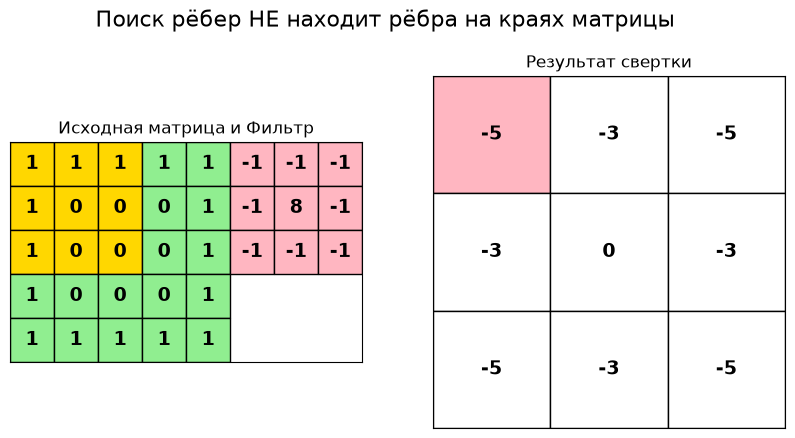

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Твоя НОВАЯ исходная матрица
img = np.array([
    [1,1,1,1,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,1,1,1,1]
])

# Фильтр обнаружения ребер (остается прежним)
filt = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Размеры
img_h, img_w = img.shape
filt_h, filt_w = filt.shape
out_h, out_w = img_h - filt_h + 1, img_w - filt_w + 1

# Матрица результатов
out = np.zeros((out_h, out_w))

# 2. Настройка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Поиск рёбер НЕ находит рёбра на краях матрицы', fontsize=16)

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Текущая позиция фильтра
    i = frame // out_w
    j = frame % out_w
    
    # --- ЛЕВАЯ ЧАСТЬ: Исходная матрица и фильтр ---
    ax1.set_title("Исходная матрица и Фильтр", fontsize=12)
    ax1.set_xlim(-0.5, img_w + filt_w - 0.5)
    ax1.set_ylim(img_h - 0.5, -0.5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_aspect('equal')
    
    # Рисуем исходную матрицу
    for r in range(img_h):
        for c in range(img_w):
            # Подсветка текущего окна
            if i <= r < i + filt_h and j <= c < j + filt_w:
                color = '#FFD700' # Золотой
            else:
                color = '#90EE90' # Салатовый
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(c, r, str(img[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Рисуем фильтр рядом (сдвигаем вправо)
    for r in range(filt_h):
        for c in range(filt_w):
            rect = plt.Rectangle((img_w + c - 0.5, r - 0.5), 1, 1, facecolor='#FFB6C1', edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(img_w + c, r, str(filt[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Текст с расчетом
    window = img[i:i+filt_h, j:j+filt_w]
    calc_sum = np.sum(window * filt)

    # --- ПРАВАЯ ЧАСТЬ: Результат свертки ---
    ax2.set_title("Результат свертки", fontsize=12)
    ax2.set_xlim(-0.5, out_w - 0.5)
    ax2.set_ylim(out_h - 0.5, -0.5)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')
    
    for r in range(out_h):
        for c in range(out_w):
            # Подсветка текущего результата
            if r == i and c == j:
                color = '#FFB6C1' # Розовый
                # Обновляем значение только когда дошли до этой ячейки
                out[r, c] = calc_sum 
            else:
                color = '#FFFFFF' # Белый
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax2.add_patch(rect)
            ax2.text(c, r, str(int(out[r, c])), ha='center', va='center', fontsize=14, fontweight='bold')

# 3. Создание анимации
# Всего кадров: 3x3 = 9
anim = animation.FuncAnimation(fig, update, frames=out_h * out_w, interval=1000, repeat=False)

# 4. Сохранение в GIF
print("Создаю GIF... Это может занять несколько секунд.")
anim.save('convolution_square.gif', writer='pillow', fps=1)
print("Готово! Файл 'convolution_square.gif' сохранен в текущей папке.")

Создаю GIF...
Готово! Файл 'convolution_padding.gif' сохранен.


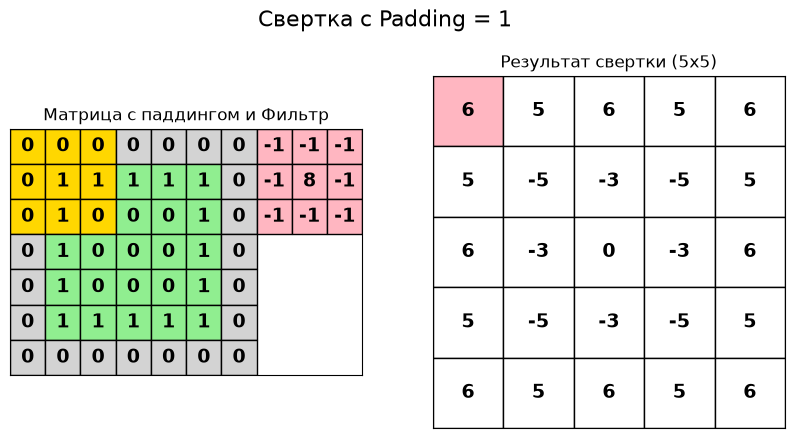

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Твоя исходная матрица 5x5
original_img = np.array([
    [1,1,1,1,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,1,1,1,1]
])

# Добавляем паддинг (рамку из нулей) толщиной 1
pad = 1
img_padded = np.pad(original_img, pad, mode='constant', constant_values=0)

# Фильтр обнаружения ребер
filt = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Размеры (теперь img_padded имеет размер 7x7)
img_h, img_w = img_padded.shape
filt_h, filt_w = filt.shape
out_h, out_w = img_h - filt_h + 1, img_w - filt_w + 1 # Результат снова 5x5

# Матрица результатов
out = np.zeros((out_h, out_w))

# 2. Настройка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Свертка с Padding = 1', fontsize=16)

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Текущая позиция фильтра
    i = frame // out_w
    j = frame % out_w
    
    # --- ЛЕВАЯ ЧАСТЬ: Исходная матрица и фильтр ---
    ax1.set_title("Матрица с паддингом и Фильтр", fontsize=12)
    ax1.set_xlim(-0.5, img_w + filt_w - 0.5)
    ax1.set_ylim(img_h - 0.5, -0.5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_aspect('equal')
    
    # Рисуем матрицу с паддингом
    for r in range(img_h):
        for c in range(img_w):
            # Проверяем, является ли ячейка паддингом (крайние ряды/столбцы)
            is_padding = (r < pad) or (r >= img_h - pad) or (c < pad) or (c >= img_w - pad)
            # Проверяем, попадает ли ячейка под текущее окно фильтра
            is_under_kernel = (i <= r < i + filt_h) and (j <= c < j + filt_w)
            
            # ВАЖНО: Сначала проверяем попадание под ядро, чтобы подсветка работала и на паддинге
            if is_under_kernel:
                color = '#FFD700' # Золотой для текущего окна фильтра
            elif is_padding:
                color = '#D3D3D3' # Серый для паддинга
            else:
                color = '#90EE90' # Салатовый для исходных данных
                
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(c, r, str(img_padded[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Рисуем фильтр рядом (сдвигаем вправо)
    for r in range(filt_h):
        for c in range(filt_w):
            rect = plt.Rectangle((img_w + c - 0.5, r - 0.5), 1, 1, facecolor='#FFB6C1', edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(img_w + c, r, str(filt[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')

    # Текст с суммой убран

    # --- ПРАВАЯ ЧАСТЬ: Результат свертки ---
    ax2.set_title("Результат свертки (5x5)", fontsize=12)
    ax2.set_xlim(-0.5, out_w - 0.5)
    ax2.set_ylim(out_h - 0.5, -0.5)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')
    
    for r in range(out_h):
        for c in range(out_w):
            # Подсветка текущего результата
            if r == i and c == j:
                color = '#FFB6C1' # Розовый
                # Вычисляем значение
                window = img_padded[i:i+filt_h, j:j+filt_w]
                out[r, c] = np.sum(window * filt)
            else:
                color = '#FFFFFF' # Белый
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax2.add_patch(rect)
            ax2.text(c, r, str(int(out[r, c])), ha='center', va='center', fontsize=14, fontweight='bold')

# 3. Создание анимации
anim = animation.FuncAnimation(fig, update, frames=out_h * out_w, interval=500, repeat=False)

# 4. Сохранение в GIF
print("Создаю GIF...")
anim.save('convolution_padding.gif', writer='pillow', fps=2)
print("Готово! Файл 'convolution_padding.gif' сохранен.")

Создаю GIF со stride=2...
Готово! Файл 'convolution_stride2.gif' сохранен.


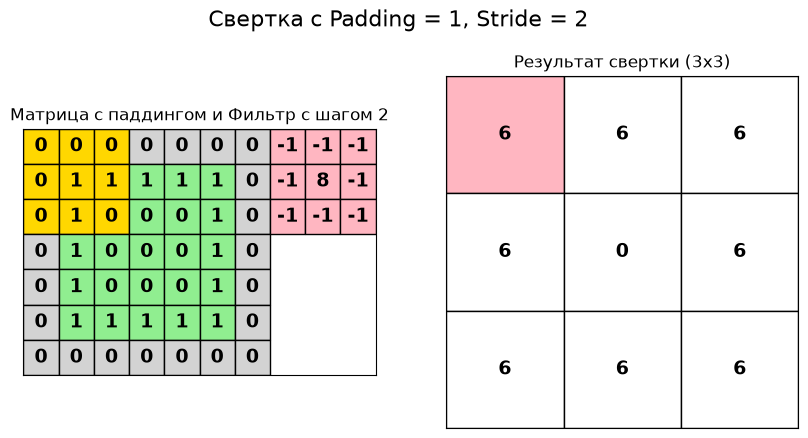

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Твоя исходная матрица 5x5
original_img = np.array([
    [1,1,1,1,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [1,1,1,1,1]
])

# Добавляем паддинг (рамку из нулей) толщиной 1
pad = 1
img_padded = np.pad(original_img, pad, mode='constant', constant_values=0)

# Фильтр обнаружения ребер
filt = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Параметры свертки
stride = 2  # ШАГ СВЕРТКИ

# Размеры
img_h, img_w = img_padded.shape
filt_h, filt_w = filt.shape

# Расчет размера выхода с учетом stride
out_h = (img_h - filt_h) // stride + 1
out_w = (img_w - filt_w) // stride + 1

# Матрица результатов (теперь 3x3)
out = np.zeros((out_h, out_w))

# 2. Настройка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Свертка с Padding = 1, Stride = 2', fontsize=16)

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Текущая позиция ядра в координатах ВЫХОДНОЙ матрицы
    i = frame // out_w
    j = frame % out_w
    
    # Координаты верхнего левого угла окна в ВХОДНОЙ (padded) матрице
    pos_i = i * stride
    pos_j = j * stride
    
    # --- ЛЕВАЯ ЧАСТЬ: Исходная матрица и фильтр ---
    ax1.set_title("Матрица с паддингом и Фильтр с шагом 2", fontsize=12)
    ax1.set_xlim(-0.5, img_w + filt_w - 0.5)
    ax1.set_ylim(img_h - 0.5, -0.5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_aspect('equal')
    
    # Рисуем матрицу с паддингом
    for r in range(img_h):
        for c in range(img_w):
            # Проверяем, является ли ячейка паддингом
            is_padding = (r < pad) or (r >= img_h - pad) or (c < pad) or (c >= img_w - pad)
            
            # Проверяем, попадает ли ячейка под текущее окно фильтра (с учетом stride)
            is_under_kernel = (pos_i <= r < pos_i + filt_h) and (pos_j <= c < pos_j + filt_w)
            
            # Приоритет цвета: сначала ядро, потом паддинг, потом данные
            if is_under_kernel:
                color = '#FFD700' # Золотой для текущего окна фильтра
            elif is_padding:
                color = '#D3D3D3' # Серый для паддинга
            else:
                color = '#90EE90' # Салатовый для исходных данных
                
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(c, r, str(img_padded[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')
            
    # Рисуем фильтр рядом (сдвигаем вправо)
    for r in range(filt_h):
        for c in range(filt_w):
            rect = plt.Rectangle((img_w + c - 0.5, r - 0.5), 1, 1, facecolor='#FFB6C1', edgecolor='black')
            ax1.add_patch(rect)
            ax1.text(img_w + c, r, str(filt[r, c]), ha='center', va='center', fontsize=14, fontweight='bold')

    # --- ПРАВАЯ ЧАСТЬ: Результат свертки ---
    ax2.set_title(f"Результат свертки ({out_h}x{out_w})", fontsize=12)
    ax2.set_xlim(-0.5, out_w - 0.5)
    ax2.set_ylim(out_h - 0.5, -0.5)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')
    
    for r in range(out_h):
        for c in range(out_w):
            # Подсветка текущего результата
            if r == i and c == j:
                color = '#FFB6C1' # Розовый
                # Вычисляем значение свертки для текущего окна
                window = img_padded[pos_i:pos_i+filt_h, pos_j:pos_j+filt_w]
                out[r, c] = np.sum(window * filt)
            else:
                color = '#FFFFFF' # Белый
                
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax2.add_patch(rect)
            ax2.text(c, r, str(int(out[r, c])), ha='center', va='center', fontsize=14, fontweight='bold')

# 3. Создание анимации
# Всего кадров теперь 3x3 = 9
anim = animation.FuncAnimation(fig, update, frames=out_h * out_w, interval=800, repeat=False)

# 4. Сохранение в GIF
print("Создаю GIF со stride=2...")
anim.save('convolution_stride2.gif', writer='pillow', fps=1.5)
print("Готово! Файл 'convolution_stride2.gif' сохранен.")

Создаю GIF для Max Pooling... Это может занять несколько секунд.
Готово! Файл 'maxpooling.gif' сохранен в текущей папке.


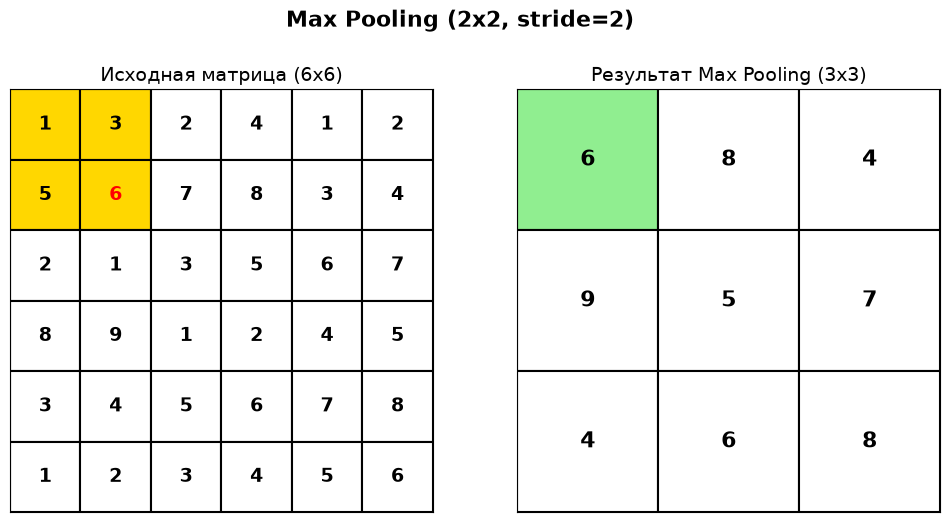

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Исходная матрица 6x6
img = np.array([
    [1, 3, 2, 4, 1, 2],
    [5, 6, 7, 8, 3, 4],
    [2, 1, 3, 5, 6, 7],
    [8, 9, 1, 2, 4, 5],
    [3, 4, 5, 6, 7, 8],
    [1, 2, 3, 4, 5, 6]
])

# Параметры Max Pooling
pool_size = 2
stride = 2

# Размеры
img_h, img_w = img.shape
out_h = (img_h - pool_size) // stride + 1
out_w = (img_w - pool_size) // stride + 1

# Матрица результатов (3x3)
out = np.zeros((out_h, out_w))

# 2. Настройка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Max Pooling (2x2, stride=2)', fontsize=16, fontweight='bold')

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Текущая позиция окна в выходной матрице
    i = frame // out_w
    j = frame % out_w
    
    # Координаты верхнего левого угла окна в исходной матрице
    pos_i = i * stride
    pos_j = j * stride
    
    # --- ЛЕВАЯ ЧАСТЬ: Исходная матрица ---
    ax1.set_title("Исходная матрица (6x6)", fontsize=14)
    ax1.set_xlim(-0.5, img_w - 0.5)
    ax1.set_ylim(img_h - 0.5, -0.5)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_aspect('equal')
    
    # Извлекаем текущее окно и находим максимум
    window = img[pos_i:pos_i+pool_size, pos_j:pos_j+pool_size]
    max_val = np.max(window)
    
    # Рисуем исходную матрицу
    for r in range(img_h):
        for c in range(img_w):
            # Проверяем, попадает ли ячейка в текущее окно
            is_in_window = (pos_i <= r < pos_i+pool_size) and (pos_j <= c < pos_j+pool_size)
            
            if is_in_window:
                color = '#FFD700' # Золотой для текущего окна
            else:
                color = '#FFFFFF' # Белый для остальных
                
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black', linewidth=1.5)
            ax1.add_patch(rect)
            
            # Подсвечиваем максимальное значение красным цветом и делаем его жирным
            text_color = '#FF0000' if (is_in_window and img[r, c] == max_val) else 'black'
            ax1.text(c, r, str(img[r, c]), ha='center', va='center', fontsize=14, 
                     fontweight='bold', color=text_color)
    


    # --- ПРАВАЯ ЧАСТЬ: Результат Max Pooling ---
    ax2.set_title("Результат Max Pooling (3x3)", fontsize=14)
    ax2.set_xlim(-0.5, out_w - 0.5)
    ax2.set_ylim(out_h - 0.5, -0.5)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_aspect('equal')
    
    for r in range(out_h):
        for c in range(out_w):
            # Логика окрашивания ячеек результата
            if r == i and c == j:
                out[r, c] = max_val # Записываем текущий максимум
                color = '#90EE90' # Зеленый для текущей ячейки
            elif r < i or (r == i and c < j):
                color = '#D3D3D3' # Серый для уже заполненных ячеек
            else:
                color = '#FFFFFF' # Белый для будущих ячеек
                
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black', linewidth=1.5)
            ax2.add_patch(rect)
            ax2.text(c, r, str(int(out[r, c])), ha='center', va='center', fontsize=16, fontweight='bold')

# 3. Создание анимации
# Всего кадров: 3x3 = 9
anim = animation.FuncAnimation(fig, update, frames=out_h * out_w, interval=1500, repeat=False)

# 4. Сохранение в GIF
print("Создаю GIF для Max Pooling... Это может занять несколько секунд.")
anim.save('maxpooling.gif', writer='pillow', fps=0.5)
print("Готово! Файл 'maxpooling.gif' сохранен в текущей папке.")

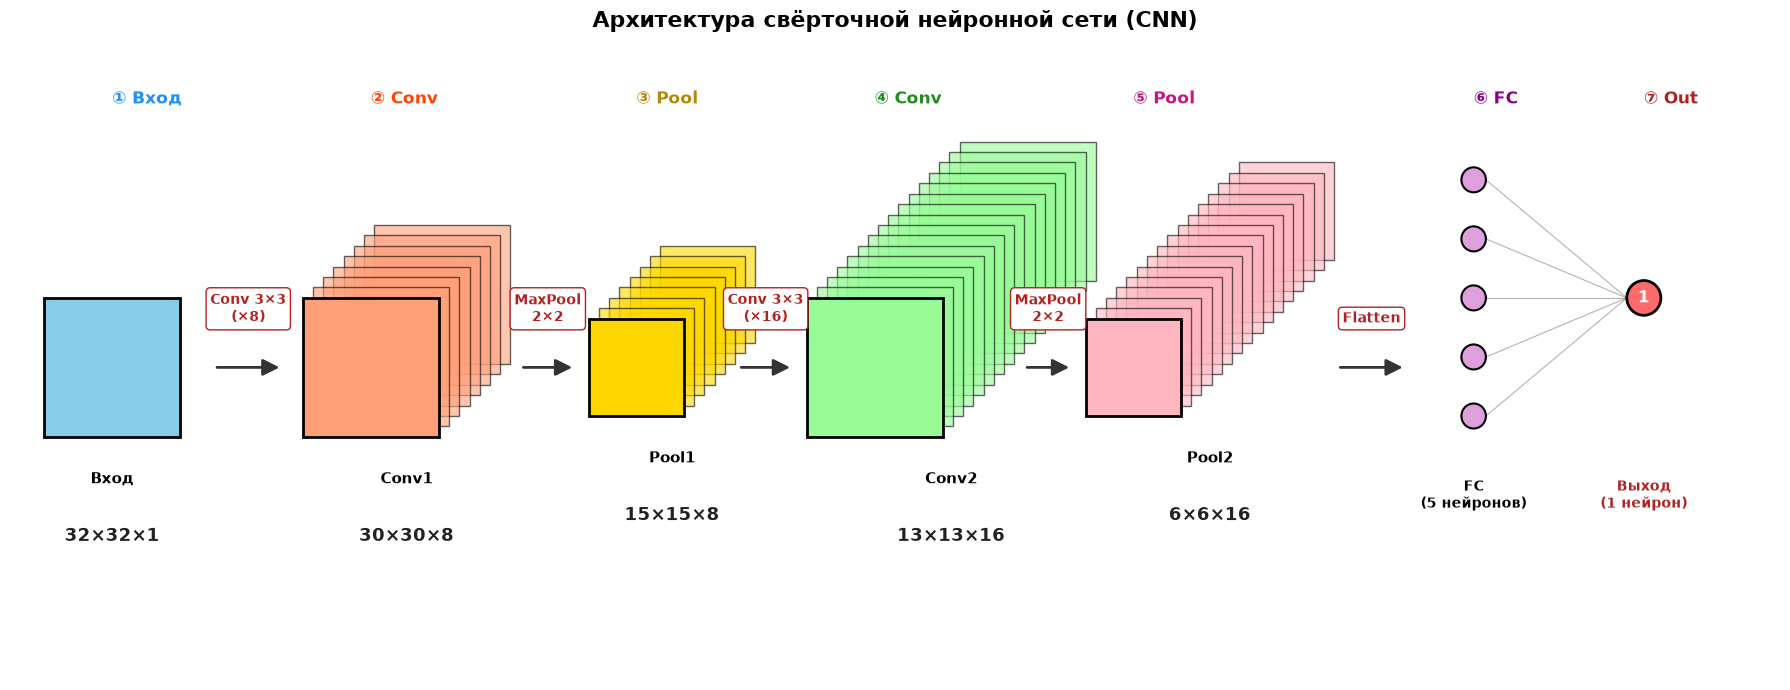

Схема сохранена в файл 'cnn_architecture.png'


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 26)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('Архитектура свёрточной нейронной сети (CNN)',
             fontsize=16, fontweight='bold', pad=20)

# ---------- Функция для рисования "стопки" карт признаков ----------
def draw_stack(ax, x, y, w, h, depth, color, label, sublabel, offset=0.15):
    for i in range(depth - 1, 0, -1):
        rect = patches.Rectangle((x + i*offset, y + i*offset), w, h,
                                 facecolor=color, edgecolor='black',
                                 linewidth=1, alpha=0.6)
        ax.add_patch(rect)
    rect = patches.Rectangle((x, y), w, h,
                             facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2 + (depth-1)*offset/2, y - 0.5, label,
            ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(x + w/2 + (depth-1)*offset/2, y - 1.3, sublabel,
            ha='center', va='top', fontsize=13, fontweight='bold',
            color='#222')

# ---------- Функция для рисования стрелки ----------
def draw_arrow(ax, x1, y1, x2, y2, label='', color='#333'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='-|>', mutation_scale=25,
                            linewidth=2, color=color)
    ax.add_patch(arrow)
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.6, label,
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                color='#B22222',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#B22222', linewidth=1))

# ---------- Параметры (теперь всё квадратное) ----------
base_y = 3.5
h = 2.0            # ← было 2.5, стало 2.0 (чтобы совпало с w1)
w1 = 2.0           # главные блоки — квадрат 2×2
h_small = 1.4      # блоки после пулинга — квадрат 1.4×1.4
w_small = 1.4
mid_y = base_y + h/2          # вертикальный центр главных блоков (= 4.5)
pool_y = mid_y - h_small/2    # чтобы pool-блоки были центрированы по стрелке (= 3.8)

# ---------- 1. ВХОД ----------
draw_stack(ax, 0.5, base_y, w1, h, depth=1, color='#87CEEB',
           label='Вход', sublabel='32×32×1')

draw_arrow(ax, 3.0, mid_y, 4.0, mid_y, label='Conv 3×3\n(×8)')

# ---------- 2. CONV1 ----------
draw_stack(ax, 4.3, base_y, w1, h, depth=8, color='#FFA07A',
           label='Conv1', sublabel='30×30×8')

draw_arrow(ax, 7.5, mid_y, 8.3, mid_y, label='MaxPool\n2×2')

# ---------- 3. POOL1 ----------
draw_stack(ax, 8.5, pool_y, w_small, h_small, depth=8,
           color='#FFD700', label='Pool1', sublabel='15×15×8')

draw_arrow(ax, 10.7, mid_y, 11.5, mid_y, label='Conv 3×3\n(×16)')

# ---------- 4. CONV2 ----------
draw_stack(ax, 11.7, base_y, w1, h, depth=16, color='#98FB98',
           label='Conv2', sublabel='13×13×16')

draw_arrow(ax, 14.9, mid_y, 15.6, mid_y, label='MaxPool\n2×2')

# ---------- 5. POOL2 ----------
draw_stack(ax, 15.8, pool_y, w_small, h_small, depth=16,
           color='#FFB6C1', label='Pool2', sublabel='6×6×16')

# ---------- 6. FLATTEN + FC ----------
draw_arrow(ax, 19.5, mid_y, 20.5, mid_y, label='Flatten')

fc_x = 21.5
fc_neurons_y = [base_y + 0.3, base_y + 1.15, base_y + 2.0, base_y + 2.85, base_y + 3.7]
for yy in fc_neurons_y:
    circle = patches.Circle((fc_x, yy), 0.18, facecolor='#DDA0DD',
                            edgecolor='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)

ax.text(fc_x, base_y - 0.6, 'FC\n(5 нейронов)', ha='center', va='top',
        fontsize=10, fontweight='bold')

# ---------- 7. ВЫХОДНОЙ НЕЙРОН ----------
out_x = 24.0
out_y = base_y + 2.0

for yy in fc_neurons_y:
    ax.plot([fc_x + 0.18, out_x - 0.25], [yy, out_y], color='gray',
            linewidth=0.8, alpha=0.6, zorder=1)

circle_out = patches.Circle((out_x, out_y), 0.25, facecolor='#FF6B6B',
                            edgecolor='black', linewidth=2, zorder=5)
ax.add_patch(circle_out)
ax.text(out_x, out_y, '1', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white', zorder=6)
ax.text(out_x, base_y - 0.6, 'Выход\n(1 нейрон)', ha='center', va='top',
        fontsize=10, fontweight='bold', color='#B22222')

# ---------- Легенда слоёв ----------
ax.text(1.5, 8.3, '① Вход', fontsize=12, fontweight='bold', color='#1E90FF')
ax.text(5.3, 8.3, '② Conv', fontsize=12, fontweight='bold', color='#FF4500')
ax.text(9.2, 8.3, '③ Pool', fontsize=12, fontweight='bold', color='#B8860B')
ax.text(12.7, 8.3, '④ Conv', fontsize=12, fontweight='bold', color='#228B22')
ax.text(16.5, 8.3, '⑤ Pool', fontsize=12, fontweight='bold', color='#C71585')
ax.text(21.5, 8.3, '⑥ FC', fontsize=12, fontweight='bold', color='#8B008B')
ax.text(24.0, 8.3, '⑦ Out', fontsize=12, fontweight='bold', color='#B22222')

plt.tight_layout()
plt.savefig('cnn_architecture.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

print("Схема сохранена в файл 'cnn_architecture.png'")

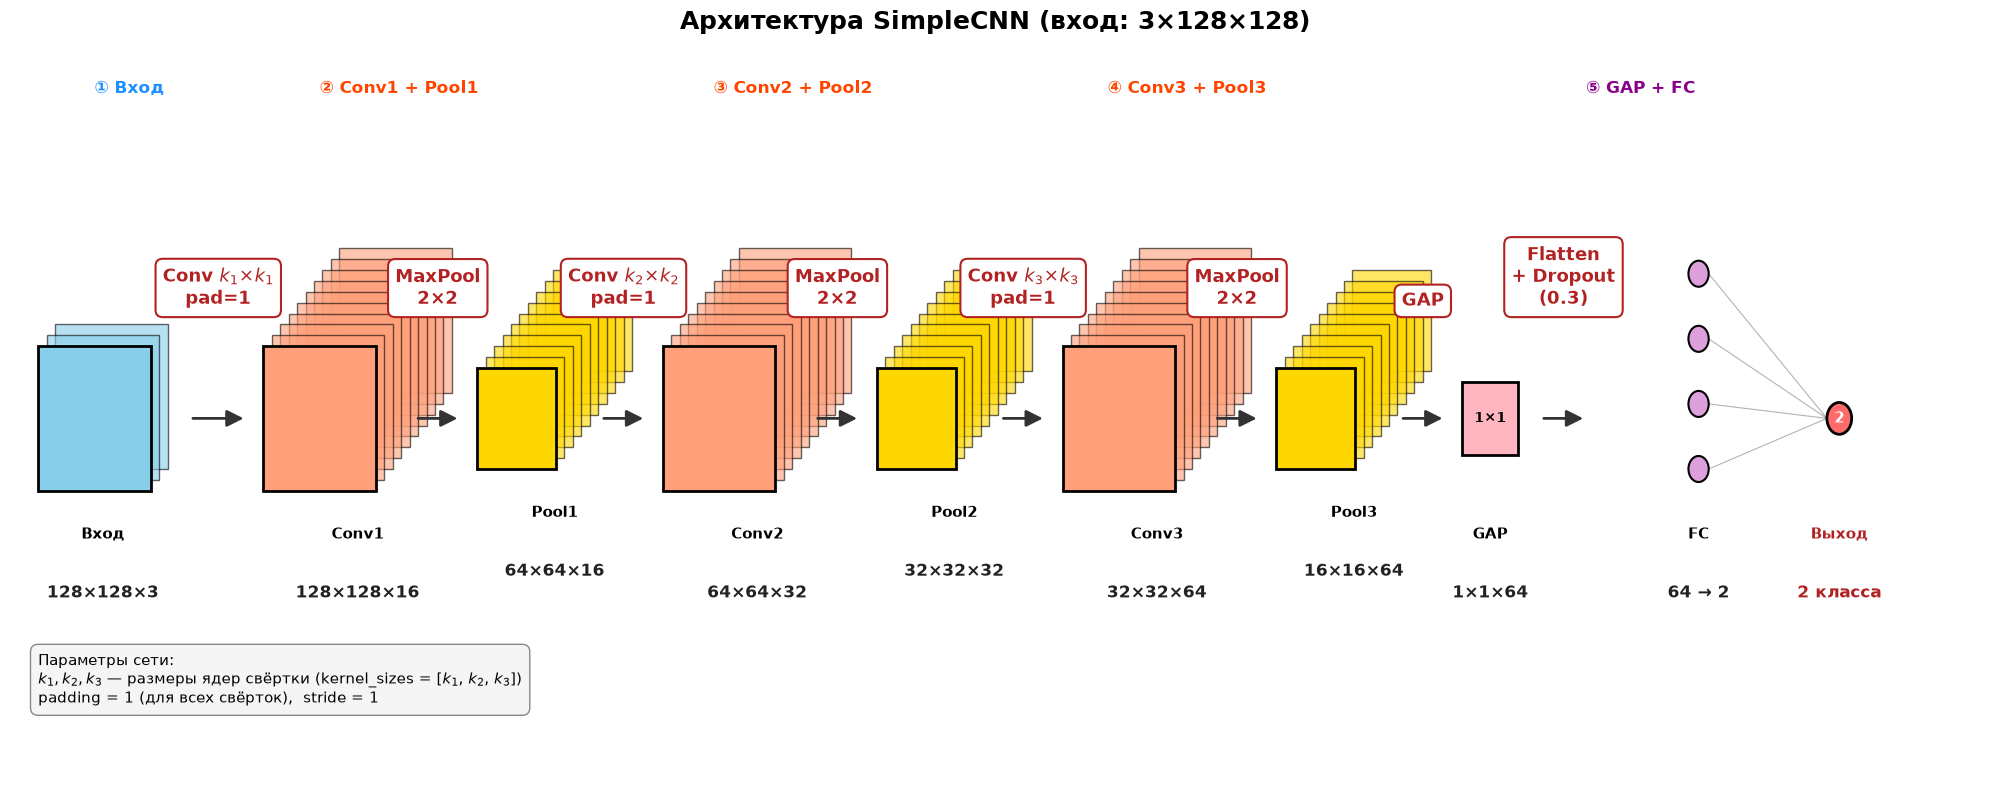

Схема сохранена в файл 'simplecnn_architecture_params.png'


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(20, 8))
ax.set_xlim(0, 35)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Архитектура SimpleCNN (вход: 3×128×128)',
             fontsize=18, fontweight='bold', pad=20)

# ---------- Функция для рисования "стопки" карт признаков ----------
def draw_stack(ax, x, y, w, h, depth, color, label, sublabel, offset=0.15):
    drawn_depth = min(depth, 10)
    for i in range(drawn_depth - 1, 0, -1):
        rect = patches.Rectangle((x + i*offset, y + i*offset), w, h,
                                 facecolor=color, edgecolor='black',
                                 linewidth=1, alpha=0.6)
        ax.add_patch(rect)
    rect = patches.Rectangle((x, y), w, h,
                             facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    center_x = x + w/2 + (drawn_depth-1)*offset/2
    ax.text(center_x, y - 0.5, label,
            ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(center_x, y - 1.3, sublabel,
            ha='center', va='top', fontsize=12, fontweight='bold', color='#222')

# ---------- Функция для рисования стрелки ----------
def draw_arrow(ax, x1, y1, x2, y2, label='', color='#333'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='-|>', mutation_scale=25,
                            linewidth=2, color=color)
    ax.add_patch(arrow)
    if label:
        # ↓↓↓ Подписи подняли выше (+1.5 вместо +0.6) и увеличили шрифт (13 вместо 10)
        ax.text((x1+x2)/2, (y1+y2)/2 + 1.5, label,
                ha='center', va='bottom', fontsize=13, fontweight='bold',
                color='#B22222',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#B22222', linewidth=1.5))

# ---------- Параметры ----------
base_y = 4.0
h = 2.0
w1 = 2.0
w_small = 1.4
mid_y = base_y + h/2

# ---------- 1. ВХОД ----------
draw_stack(ax, 0.5, base_y, w1, h, depth=3, color='#87CEEB',
           label='Вход', sublabel='128×128×3')

# ---------- 2. CONV1 + POOL1 ----------
draw_arrow(ax, 3.2, mid_y, 4.2, mid_y,
           label='Conv $k_1\\!\\times\\!k_1$\npad=1')
draw_stack(ax, 4.5, base_y, w1, h, depth=16, color='#FFA07A',
           label='Conv1', sublabel='128×128×16')
draw_arrow(ax, 7.2, mid_y, 8.0, mid_y, label='MaxPool\n2×2')
draw_stack(ax, 8.3, base_y + 0.3, w_small, h - 0.6, depth=16,
           color='#FFD700', label='Pool1', sublabel='64×64×16')

# ---------- 3. CONV2 + POOL2 ----------
draw_arrow(ax, 10.5, mid_y, 11.3, mid_y,
           label='Conv $k_2\\!\\times\\!k_2$\npad=1')
draw_stack(ax, 11.6, base_y, w1, h, depth=32, color='#FFA07A',
           label='Conv2', sublabel='64×64×32')
draw_arrow(ax, 14.3, mid_y, 15.1, mid_y, label='MaxPool\n2×2')
draw_stack(ax, 15.4, base_y + 0.3, w_small, h - 0.6, depth=32,
           color='#FFD700', label='Pool2', sublabel='32×32×32')

# ---------- 4. CONV3 + POOL3 ----------
draw_arrow(ax, 17.6, mid_y, 18.4, mid_y,
           label='Conv $k_3\\!\\times\\!k_3$\npad=1')
draw_stack(ax, 18.7, base_y, w1, h, depth=64, color='#FFA07A',
           label='Conv3', sublabel='32×32×64')
draw_arrow(ax, 21.4, mid_y, 22.2, mid_y, label='MaxPool\n2×2')
draw_stack(ax, 22.5, base_y + 0.3, w_small, h - 0.6, depth=64,
           color='#FFD700', label='Pool3', sublabel='16×16×64')

# ---------- 5. GAP ----------
draw_arrow(ax, 24.7, mid_y, 25.5, mid_y, label='GAP')
gap_x = 25.8
gap_w = 1.0
gap_h = 1.0
gap_y = mid_y - gap_h/2

rect = patches.Rectangle((gap_x, gap_y), gap_w, gap_h,
                         facecolor='#FFB6C1', edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(gap_x + gap_w/2, gap_y + gap_h/2, '1×1', ha='center', va='center',
        fontsize=10, fontweight='bold')

ax.text(gap_x + gap_w/2, base_y - 0.5, 'GAP', ha='center', va='top',
        fontsize=11, fontweight='bold')
ax.text(gap_x + gap_w/2, base_y - 1.3, '1×1×64', ha='center', va='top',
        fontsize=12, fontweight='bold', color='#222')

# ---------- 6. FLATTEN, DROPOUT, FC ----------
draw_arrow(ax, 27.2, mid_y, 28.0, mid_y, label='Flatten\n+ Dropout\n(0.3)')

fc_x = 30.0
fc_neurons_y = [base_y + 0.3, base_y + 1.2, base_y + 2.1, base_y + 3.0]
for yy in fc_neurons_y:
    circle = patches.Circle((fc_x, yy), 0.18, facecolor='#DDA0DD',
                            edgecolor='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)

ax.text(fc_x, base_y - 0.5, 'FC', ha='center', va='top',
        fontsize=11, fontweight='bold')
ax.text(fc_x, base_y - 1.3, '64 → 2', ha='center', va='top',
        fontsize=12, fontweight='bold', color='#222')

# ---------- 7. ВЫХОД ----------
out_x = 32.5
out_y = mid_y

for yy in fc_neurons_y:
    ax.plot([fc_x + 0.18, out_x - 0.22], [yy, out_y], color='gray',
            linewidth=0.8, alpha=0.6, zorder=1)

circle_out = patches.Circle((out_x, out_y), 0.22, facecolor='#FF6B6B',
                            edgecolor='black', linewidth=2, zorder=5)
ax.add_patch(circle_out)
ax.text(out_x, out_y, '2', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white', zorder=6)

ax.text(out_x, base_y - 0.5, 'Выход', ha='center', va='top',
        fontsize=11, fontweight='bold', color='#B22222')
ax.text(out_x, base_y - 1.3, '2 класса', ha='center', va='top',
        fontsize=12, fontweight='bold', color='#B22222')

# ---------- Легенда сверху ----------
ax.text(1.5, 9.5, '① Вход', fontsize=12, fontweight='bold', color='#1E90FF')
ax.text(5.5, 9.5, '② Conv1 + Pool1', fontsize=12, fontweight='bold', color='#FF4500')
ax.text(12.5, 9.5, '③ Conv2 + Pool2', fontsize=12, fontweight='bold', color='#FF4500')
ax.text(19.5, 9.5, '④ Conv3 + Pool3', fontsize=12, fontweight='bold', color='#FF4500')
ax.text(28.0, 9.5, '⑤ GAP + FC', fontsize=12, fontweight='bold', color='#8B008B')

# ---------- Легенда параметров (внизу слева) ----------
legend_text = (
    'Параметры сети:\n'
    '$k_1, k_2, k_3$ — размеры ядер свёртки (kernel_sizes = [$k_1$, $k_2$, $k_3$])\n'
    'padding = 1 (для всех свёрток),  stride = 1'
)
ax.text(0.5, 1.0, legend_text,
        fontsize=11, va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5',
                  edgecolor='#888', linewidth=1))

plt.tight_layout()
plt.savefig('simplecnn_architecture_params.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

print("Схема сохранена в файл 'simplecnn_architecture_params.png'")

In [13]:
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import ImageFormatter
from PIL import Image, ImageDraw, ImageFont

# ---------- 1. Исходный код ----------
code = '''
    def forward(self, x):
        # 128 -> 64
        x = self.pool(F.relu(self.conv1(x)))
        # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))
        # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))
        
        x = self.gap(x)
        x = x.flatten(1)
        x = self.drop(x)
        return self.fc(x)
'''

# ---------- 2. Рендер с подсветкой синтаксиса в PNG ----------
formatter = ImageFormatter(
    font_name='DejaVu Sans Mono',   # моноширинный шрифт, есть почти везде
    font_size=22,                   # крупный шрифт для презентации
    line_numbers=True,              # номера строк
    line_number_bg='#F0F0F0',       # фон номеров строк
    line_number_fg='#888888',       # цвет номеров строк
    style='friendly',               # приятная светлая тема
    image_pad=25,                   # отступы внутри картинки
    line_pad=6,                     # межстрочный интервал
    line_number_start=13,
)

output = 'cnn_code_listing2.png'
with open(output, 'wb') as f:
    f.write(highlight(code, PythonLexer(), formatter))

# ---------- 3. Оборачиваем в рамку в стиле схемы ----------
img = Image.open(output).convert('RGB')

# Создаём холст чуть больше — для рамки и заголовка
pad = 30
title_h = 70
new_w = img.width + pad * 2
new_h = img.height + pad * 2 + title_h

canvas = Image.new('RGB', (new_w, new_h), 'white')
draw = ImageDraw.Draw(canvas)

# Рисуем рамку вокруг области кода (в стиле схемы, но потоньше)
border_color = '#888888'
canvas.paste(img, (pad, pad + title_h))

draw.rectangle(
    [(pad - 1, pad + title_h - 1),
     (pad + img.width, pad + title_h + img.height)],
    outline=border_color, width=3
)

# ---------- 4. Заголовок в стиле схемы ----------
try:
    title_font = ImageFont.truetype('DejaVuSans-Bold.ttf', 30)
except IOError:
    title_font = ImageFont.load_default()

title = 'simple_cnn.py'
draw.text((pad, 20), title, fill='#1E90FF', font=title_font)

# Правый нижний угол — имя архитектуры (мелкий серый текст)
try:
    small_font = ImageFont.truetype('DejaVuSans.ttf', 18)
except IOError:
    small_font = ImageFont.load_default()

draw.text(
    (new_w - pad - 220, pad + title_h + img.height + 10),
    'SimpleCNN — код модели',
    fill='#666666', font=small_font
)

# Сохраняем финальный файл
final = 'cnn_code_listing_final2.png'
canvas.save(final)
print(f'Готово! Файл {final} сохранён.')

# Показать результат
canvas.show()

Готово! Файл cnn_code_listing_final2.png сохранён.


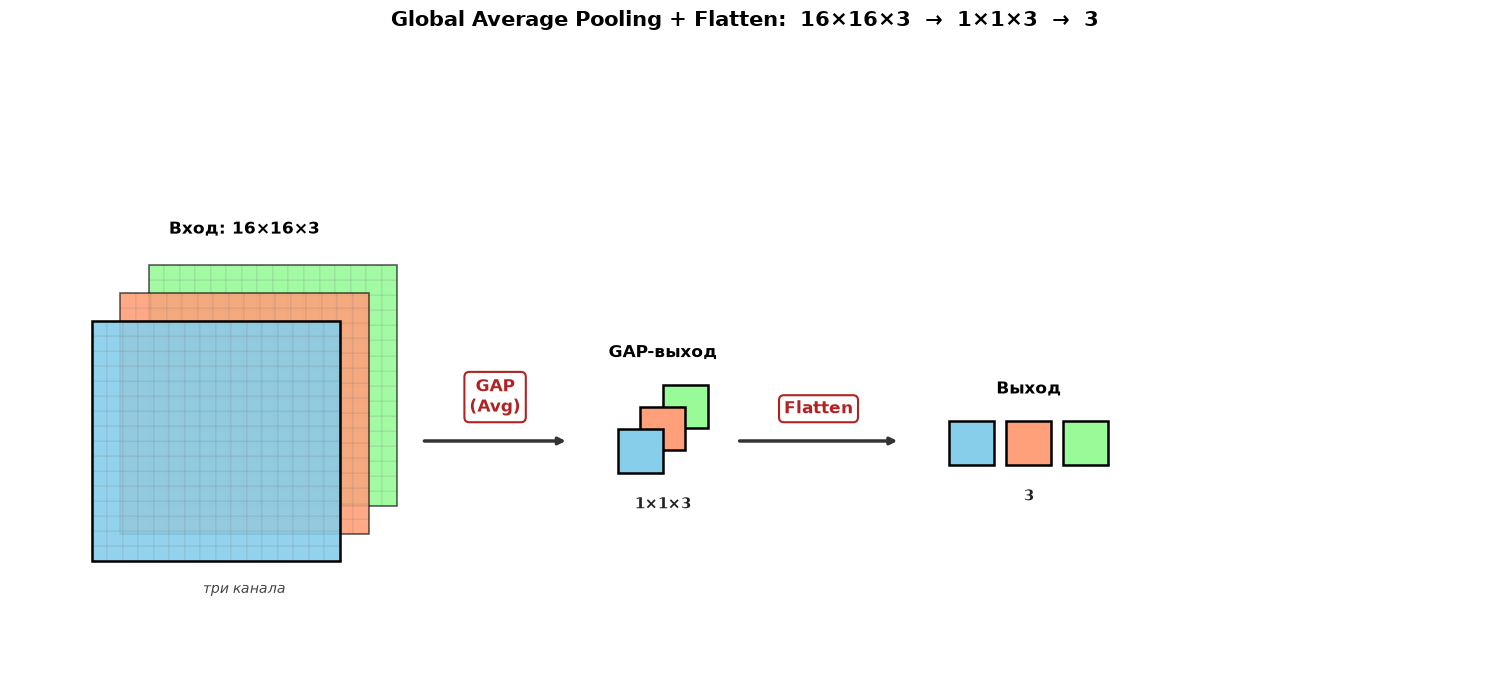

Сохранено: gap_flatten_demo.png


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(15, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Global Average Pooling + Flatten:  16×16×3  →  1×1×3  →  3',
             fontsize=15, fontweight='bold', pad=15)

np.random.seed(1)
mats = [np.random.randint(1, 10, (16, 16)) for _ in range(3)]
colors = ['#87CEEB', '#FFA07A', '#98FB98']

# ---------- Стопка 3 матриц 16×16 ----------
cell = 0.19
base_x, base_y = 1.0, 1.5
offset = 0.35

for k in [2, 1, 0]:
    x0 = base_x + k * offset
    y0 = base_y + k * offset
    for r in range(16):
        for c in range(16):
            ax.add_patch(patches.Rectangle(
                (x0 + c*cell, y0 + r*cell), cell, cell,
                facecolor=colors[k], edgecolor='gray',
                linewidth=0.15, alpha=0.9))
    ax.add_patch(patches.Rectangle(
        (x0, y0), 16*cell, 16*cell,
        facecolor='none', edgecolor='black',
        linewidth=1.8 if k == 0 else 1.2,
        alpha=1.0 if k == 0 else 0.6))

stack_w = 16*cell + 2*offset
ax.text(base_x + stack_w/2, base_y + 16*cell + 2*offset + 0.4,
        'Вход: 16×16×3', ha='center', fontsize=12, fontweight='bold')
ax.text(base_x + stack_w/2, base_y - 0.4, 'три канала',
        ha='center', fontsize=10, style='italic', color='#444')

# ---------- Стрелка GAP ----------
arrow_x1 = base_x + stack_w + 0.3
arrow_x2 = arrow_x1 + 1.8
arrow_y = base_y + 8*cell
ax.annotate('', xy=(arrow_x2, arrow_y), xytext=(arrow_x1, arrow_y),
            arrowprops=dict(arrowstyle='-|>', color='#333', lw=2.5))
ax.text((arrow_x1 + arrow_x2)/2, arrow_y + 0.3,
        'GAP\n(Avg)', ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#B22222',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#B22222', linewidth=1.5))

# ---------- Выход GAP: стопка 1×1×3 ----------
out_x = arrow_x2 + 0.6
out_y = arrow_y - 0.4
cell_out = 0.55
out_offset = 0.28

for k in [2, 1, 0]:
    x0 = out_x + k * out_offset
    y0 = out_y + k * out_offset
    ax.add_patch(patches.Rectangle(
        (x0, y0), cell_out, cell_out,
        facecolor=colors[k], edgecolor='black', linewidth=1.8))

ax.text(out_x + cell_out/2 + out_offset,
        out_y + cell_out + 2*out_offset + 0.35,
        'GAP-выход', ha='center', fontsize=12, fontweight='bold')
ax.text(out_x + cell_out/2 + out_offset,
        out_y - 0.45, '1×1×3', ha='center',
        fontsize=11, fontweight='bold', color='#222')

# ---------- Стрелка Flatten ----------
flat_x1 = out_x + cell_out + 2*out_offset + 0.35
flat_x2 = flat_x1 + 2.0
ax.annotate('', xy=(flat_x2, arrow_y), xytext=(flat_x1, arrow_y),
            arrowprops=dict(arrowstyle='-|>', color='#333', lw=2.5))
ax.text((flat_x1 + flat_x2)/2, arrow_y + 0.3,
        'Flatten', ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#B22222',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#B22222', linewidth=1.5))

# ---------- Выход Flatten: вектор (3,) ----------
vec_x = flat_x2 + 0.6
vec_y = arrow_y - 0.3
vec_cell = 0.55
gap = 0.15

for k in range(3):
    x0 = vec_x + k * (vec_cell + gap)
    ax.add_patch(patches.Rectangle(
        (x0, vec_y), vec_cell, vec_cell,
        facecolor=colors[k], edgecolor='black', linewidth=1.8))

vec_w = 3 * vec_cell + 2 * gap
ax.text(vec_x + vec_w/2, vec_y + vec_cell + 0.35,
        'Выход', ha='center', fontsize=12, fontweight='bold')
ax.text(vec_x + vec_w/2, vec_y - 0.45, '3',
        ha='center', fontsize=11, fontweight='bold', color='#222')

plt.tight_layout()
plt.savefig('gap_flatten_demo.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Сохранено: gap_flatten_demo.png')

In [30]:
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import ImageFormatter
from PIL import Image, ImageDraw, ImageFont
from pygments.token import Comment

code = '''
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import ImageFormatter
from PIL import Image, ImageDraw, ImageFont

IMG_SIZE = (128, 128)            # целевой размер изображения (ширина, высота)
DATA_DIR = "data_chipolino"      # папка с изображениями

def load_and_resize(path, size=IMG_SIZE):
    img = mpimg.imread(path)
    img = (img).astype(np.uint8)                   # приводим тип к uint8 (0..255)
    img = Image.fromarray(img).resize(             # ресайз через PIL
        size, Image.BILINEAR                       # билинейная интерполяция
    )
    return np.asarray(img, dtype=np.float32) / 255.0  # нормализация: [0,255] → [0,1]
images_onion  = []
images_tomato = []

for i in range(1, 21):
    p = os.path.join(DATA_DIR, f"tomato{i}.jpg")
    images_tomato.append(load_and_resize(p))
    p = os.path.join(DATA_DIR, f"onion{i}.jpg")
    images_onion.append(load_and_resize(p))

train_lst = images_onion[:15] + images_tomato[:15]   # 15 луков + 15 помидоров = 30
test_lst  = images_onion[15:] + images_tomato[15:]   # 5 луков + 5 помидоров  = 10
X_train = np.stack(train_lst)    # (30, 128, 128, 3)
X_test  = np.stack(test_lst)     # (10, 128, 128, 3)

y_train = np.array([0]*15 + [1]*15)   # 15 нулей + 15 единиц
y_test  = np.array([0]*5  + [1]*5)    # 5 нулей + 5 единиц
'''

formatter = ImageFormatter(
    font_name='DejaVu Sans Mono',
    font_size=22,
    line_numbers=True,
    line_number_start=13,
    line_number_bg='#F0F0F0',
    line_number_fg='#888888',
    style='vs',
    image_pad=25,
    line_pad=6,
)
formatter.style.styles[Comment] = '#333333'
output = 'loader_code.png'
with open(output, 'wb') as f:
    f.write(highlight(code, PythonLexer(), formatter))

# Обёртка: заголовок + рамка
img = Image.open(output).convert('RGB')
pad, title_h = 30, 70
canvas = Image.new('RGB',
                   (img.width + pad*2, img.height + pad*2 + title_h),
                   'white')
canvas.paste(img, (pad, pad + title_h))

draw = ImageDraw.Draw(canvas)
draw.rectangle(
    [(pad - 1, pad + title_h - 1),
     (pad + img.width, pad + title_h + img.height)],
    outline='#888888', width=3
)

try:
    title_font = ImageFont.truetype('DejaVuSans-Bold.ttf', 30)
except IOError:
    title_font = ImageFont.load_default()

draw.text((pad, 20), 'load_data.py', fill='#1E90FF', font=title_font)

canvas.save('loader_code_final.png')
print('Готово: loader_code_final.png')

Готово: loader_code_final.png


In [34]:
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import ImageFormatter
from PIL import Image, ImageDraw, ImageFont

code = '''def max_pooling(input_matrix, pool_size=2, stride=2, padding=0):
    # Добавляем padding если нужно
    if padding > 0:
        input_matrix = np.pad(input_matrix, padding,
                              mode='constant', constant_values=0)

    # Размеры входной матрицы
    input_height, input_width = input_matrix.shape

    # Вычисляем размеры выходной матрицы
    output_height = (input_height - pool_size) // stride + 1
    output_width  = (input_width  - pool_size) // stride + 1

    # Инициализируем выходную матрицу
    output = np.zeros((output_height, output_width))

    # Выполняем max pooling
    for i in range(output_height):
        for j in range(output_width):
            # Вычисляем индексы для окна
            start_i = i * stride
            start_j = j * stride
            end_i = start_i + pool_size
            end_j = start_j + pool_size

            # Извлекаем окно и находим максимальное значение
            window = input_matrix[start_i:end_i, start_j:end_j]
            output[i, j] = np.max(window)
    return output
'''

formatter = ImageFormatter(
    font_name='DejaVu Sans Mono',
    font_size=22,
    line_numbers=True,
    line_number_bg='#F0F0F0',
    line_number_fg='#888888',
    style='vs',                  # ← тёмные, контрастные комментарии
    image_pad=25,
    line_pad=6,
)

output = 'maxpool_code.png'
with open(output, 'wb') as f:
    f.write(highlight(code, PythonLexer(), formatter))

# Обёртка: заголовок + рамка
img = Image.open(output).convert('RGB')
pad, title_h = 30, 70
canvas = Image.new('RGB',
                   (img.width + pad*2, img.height + pad*2 + title_h),
                   'white')
canvas.paste(img, (pad, pad + title_h))

draw = ImageDraw.Draw(canvas)
draw.rectangle(
    [(pad - 1, pad + title_h - 1),
     (pad + img.width, pad + title_h + img.height)],
    outline='#888888', width=3
)

try:
    title_font = ImageFont.truetype('DejaVuSans-Bold.ttf', 30)
except IOError:
    title_font = ImageFont.load_default()

draw.text((pad, 20), 'max_pooling.py', fill='#1E90FF', font=title_font)

canvas.save('maxpool_code_final.png')
print('Готово: maxpool_code_final.png')

Готово: maxpool_code_final.png


In [33]:
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import ImageFormatter
from PIL import Image, ImageDraw, ImageFont

code = '''def convolution(input_matrix, kernel, stride=1, padding=0):
    if padding > 0:
        input_matrix = np.pad(input_matrix, padding, mode='constant')

    # Размеры входной матрицы и ядра
    input_height, input_width = input_matrix.shape
    kernel_height, kernel_width = kernel.shape

    # Вычисляем размеры выходной матрицы
    output_height = (input_height - kernel_height) // stride + 1
    output_width  = (input_width  - kernel_width)  // stride + 1

    # Инициализируем выходную матрицу
    output = np.zeros((output_height, output_width))

    # Выполняем свертку
    for i in range(0, output_height):
        for j in range(0, output_width):
            # Вычисляем индексы для окна
            start_i = i * stride
            start_j = j * stride
            end_i = start_i + kernel_height
            end_j = start_j + kernel_width

            # Извлекаем окно и умножаем на ядро
            window = input_matrix[start_i:end_i, start_j:end_j]
            output[i, j] = np.sum(window * kernel)
    return output
'''

formatter = ImageFormatter(
    font_name='DejaVu Sans Mono',
    font_size=22,
    line_numbers=True,
    line_number_bg='#F0F0F0',
    line_number_fg='#888888',
    style='vs',
    image_pad=25,
    line_pad=6,
)

output = 'convolution_code.png'
with open(output, 'wb') as f:
    f.write(highlight(code, PythonLexer(), formatter))

img = Image.open(output).convert('RGB')
pad, title_h = 30, 70
canvas = Image.new('RGB',
                   (img.width + pad*2, img.height + pad*2 + title_h),
                   'white')
canvas.paste(img, (pad, pad + title_h))

draw = ImageDraw.Draw(canvas)
draw.rectangle(
    [(pad - 1, pad + title_h - 1),
     (pad + img.width, pad + title_h + img.height)],
    outline='#888888', width=3
)

try:
    title_font = ImageFont.truetype('DejaVuSans-Bold.ttf', 30)
except IOError:
    title_font = ImageFont.load_default()

draw.text((pad, 20), 'convolution.py', fill='#1E90FF', font=title_font)

canvas.save('convolution_code_final.png')
print('Готово: convolution_code_final.png')

Готово: convolution_code_final.png
